# ARIMA-only HPI Modeling
This notebook contains the cells required to train ARIMA models on the HPI (index_nsa) series for each city, select orders by AIC, and produce forecasts and plots.

In [33]:
# Import statements
import pandas as pd
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [34]:
# Load merged data (adjust path if needed)
final_df = pd.read_csv('final_merged_output.csv')
# Optionally filter years (match original notebook behavior)
final_df = final_df[(final_df['Year'] < 2023)]

In [35]:
# HPI ARIMA grid search per city (select by AIC)
p = d = q = range(0, 3)
pdq = list(itertools.product(p, d, q))

best_orders_raw = {}
arima_results_raw = {}

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter'])
    arima_train_size = int(len(city_df) * 0.9)
    arima_train_df = city_df.iloc[:arima_train_size]
    series = arima_train_df['index_nsa'].dropna()

    best_aic = np.inf
    best_order = None
    best_model = None

    for order in pdq:
        try:
            model = ARIMA(series, order=order)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = order
                best_model = fitted
        except Exception:
            continue

    best_orders_raw[city] = best_order
    arima_results_raw[city] = best_model
    print(f"{city}: best ARIMA order = {best_order}, AIC = {best_aic:.2f}")


c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as st

Chicago: best ARIMA order = (2, 2, 0), AIC = 403.65


c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib

Houston: best ARIMA order = (2, 2, 2), AIC = 397.26


c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib

Los Angeles: best ARIMA order = (2, 2, 1), AIC = 602.37


c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib

New York: best ARIMA order = (2, 2, 0), AIC = 478.69


c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib

Phoenix: best ARIMA order = (2, 2, 2), AIC = 619.38


----- Chicago -----
Resid length=118 mean=0.3715 std=8.7190
Saved ACF to diagnostics/Chicago_acf.png
Saved histogram to diagnostics/Chicago_resid_hist.png
Saved QQ plot to diagnostics/Chicago_qq.png


----- Houston -----
Resid length=118 mean=0.4274 std=9.5339
Saved ACF to diagnostics/Houston_acf.png
Saved histogram to diagnostics/Chicago_resid_hist.png
Saved QQ plot to diagnostics/Chicago_qq.png


----- Houston -----
Resid length=118 mean=0.4274 std=9.5339
Saved ACF to diagnostics/Houston_acf.png
Saved histogram to diagnostics/Houston_resid_hist.png
Saved QQ plot to diagnostics/Houston_qq.png


----- Los Angeles -----
Resid length=118 mean=0.5541 std=13.4589
Saved ACF to diagnostics/Los Angeles_acf.png
Saved histogram to diagnostics/Houston_resid_hist.png
Saved QQ plot to diagnostics/Houston_qq.png


----- Los Angeles -----
Resid length=118 mean=0.5541 std=13.4589
Saved ACF to diagnostics/Los Angeles_acf.png
Saved histogram to diagnostics/Los Angeles_resid_hist.png
Saved QQ plot to di

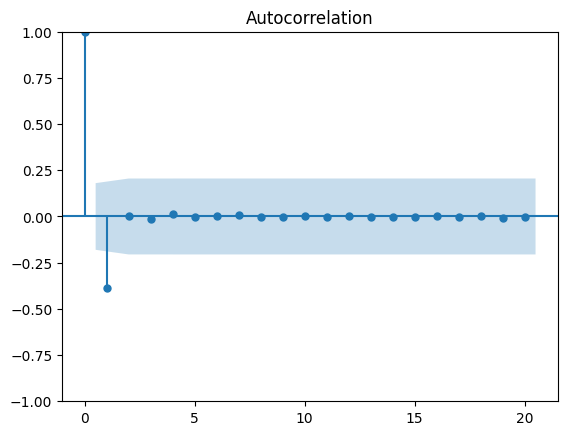

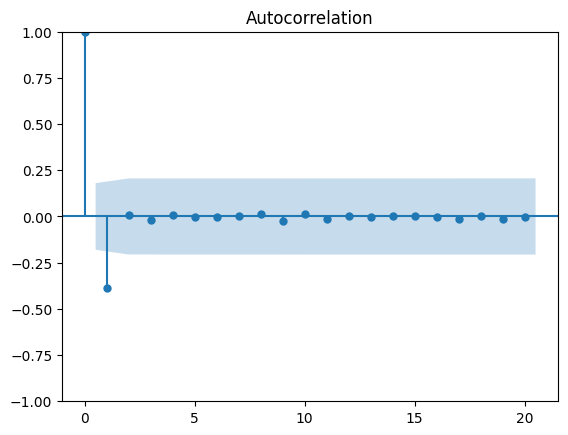

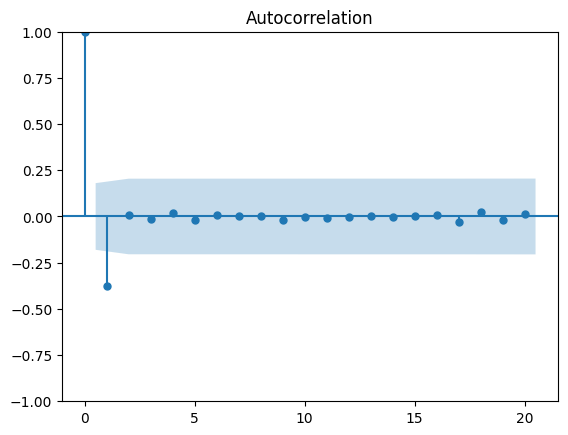

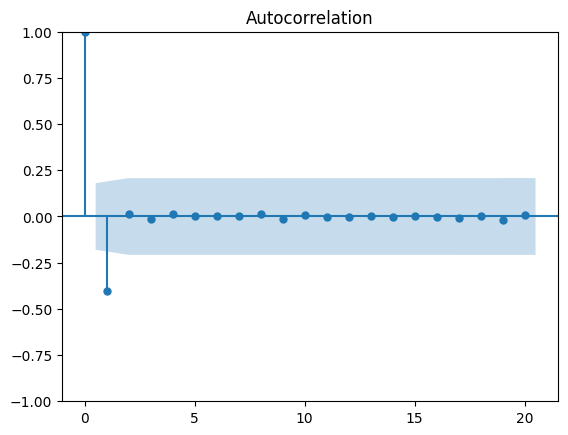

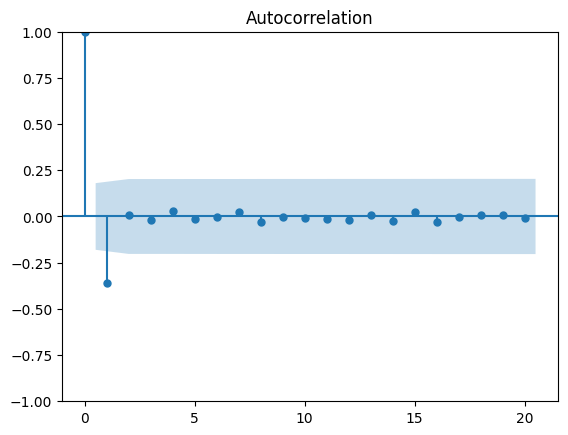

In [36]:
# Diagnostic plots on ARIMA residuals per city
# Produce only: ACF, residual histogram, and QQ plot. Save images to the `diagnostics/` folder.
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.gofplots import qqplot
import os

os.makedirs('diagnostics', exist_ok=True)

for city, model in arima_results_raw.items():
    print(f"----- {city} -----")
    if model is None:
        print("No fitted ARIMA model for city; skipping.")
        continue
    try:
        resid = model.resid
    except Exception as e:
        print("Could not get residuals:", e)
        continue

    resid = pd.Series(resid).dropna()
    print(f"Resid length={len(resid)} mean={resid.mean():.4f} std={resid.std():.4f}")

    # Plot and save ACF
    try:
        fig_acf = plot_acf(resid, lags=20)
        acf_path = f"diagnostics/{city}_acf.png"
        fig_acf.figure.savefig(acf_path)
        print('Saved ACF to', acf_path)
    except Exception as e:
        print('ACF plot failed:', e)

    # Histogram
    try:
        plt.figure()
        plt.hist(resid, bins=30)
        plt.title(f"{city} residual histogram")
        hist_path = f"diagnostics/{city}_resid_hist.png"
        plt.savefig(hist_path)
        plt.close()
        print('Saved histogram to', hist_path)
    except Exception as e:
        print('Histogram plot failed:', e)

    # QQ plot
    try:
        qqplot(resid, line='s')
        qq_path = f"diagnostics/{city}_qq.png"
        plt.title(f"{city} QQ plot")
        plt.savefig(qq_path)
        plt.close()
        print('Saved QQ plot to', qq_path)
    except Exception as e:
        print('QQ plot failed:', e)

    print('\n')

In [37]:
# Create ARIMA predictions (fit + forecast) and store in dataframe
final_df['arima_predicted_hpi'] = np.nan

for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).copy()

    arima_model = arima_results_raw.get(city)
    if arima_model is None:
        continue

    n_total = len(city_df)
    n_train = int(n_total * 0.9)

    fitted_part = arima_model.fittedvalues
    forecast_part = arima_model.get_forecast(steps=n_total - n_train).predicted_mean

    arima_pred = np.concatenate([fitted_part, forecast_part])

    if len(arima_pred) < n_total:
        arima_pred = np.pad(arima_pred, (n_total - len(arima_pred), 0), constant_values=np.nan)
    elif len(arima_pred) > n_total:
        arima_pred = arima_pred[:n_total]

    final_df.loc[city_df.index, 'arima_predicted_hpi'] = arima_pred

final_df.head()

c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\katel\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the n

,City,Year,Quarter,index_nsa,Median Household Income,Total Population,INDPRO,VIXCLS,CPI,Unemployment Rate,City GDP,arima_predicted_hpi
0,Chicago,1990,1,83.83,26301.0,2784000.0,62.107300,22.168437,5.397954,6.600000,1.116378e+08,0.000000
1,Chicago,1990,2,84.81,26301.0,2784000.0,62.544767,18.735385,5.397954,6.400000,1.149545e+08,125.745043
2,Chicago,1990,3,85.80,26301.0,2784000.0,62.799267,25.134462,5.397954,6.466667,1.170468e+08,85.790044
3,Chicago,1990,4,85.87,26301.0,2784000.0,61.834433,26.005909,5.397954,6.133333,1.166525e+08,86.788389
4,Chicago,1991,1,86.95,26584.1,2784500.0,60.673400,22.427344,4.234963,7.166667,1.178962e+08,86.201299


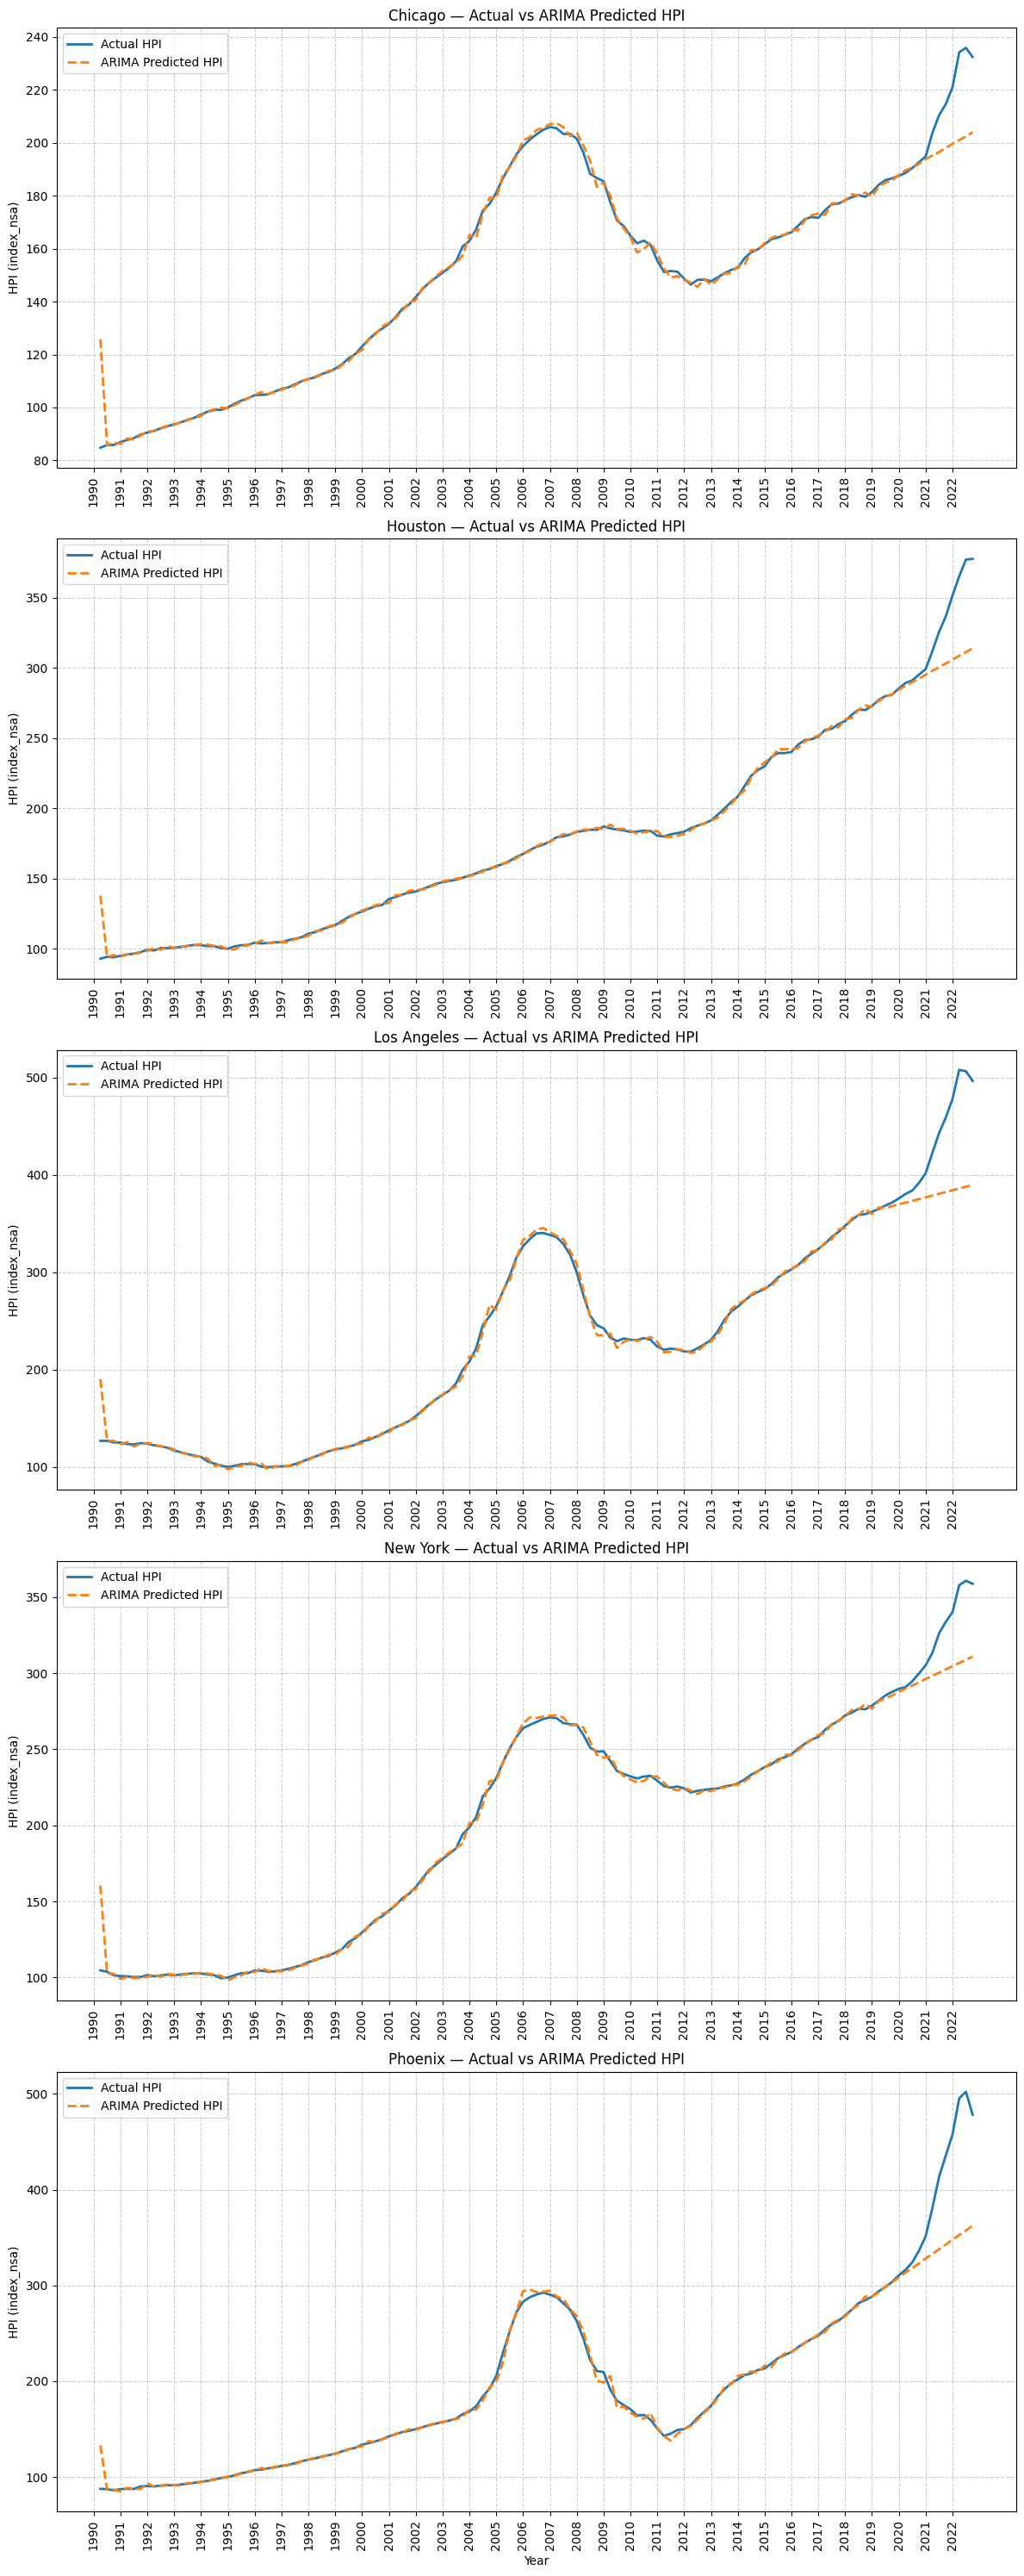

In [38]:
# Simple plot: Actual vs ARIMA Predicted HPI per city
final_df = final_df.sort_values(['City', 'Year', 'Quarter'])
cities = final_df['City'].unique()

fig, axes = plt.subplots(len(cities), 1, figsize=(12, 6 * len(cities)), sharex=False)

for ax, city in zip(axes, cities):
    city_df = final_df[final_df['City'] == city].copy()
    city_df = city_df.iloc[1:]

    city_df['TimeIndex'] = (city_df['Year'] - city_df['Year'].min()) * 4 + (city_df['Quarter'] - 1)

    ax.plot(city_df['TimeIndex'], city_df['index_nsa'], label='Actual HPI', linewidth=2)
    ax.plot(city_df['TimeIndex'], city_df['arima_predicted_hpi'], label='ARIMA Predicted HPI', linestyle='--', linewidth=2)

    ax.set_title(f"{city} — Actual vs ARIMA Predicted HPI")
    ax.set_ylabel('HPI (index_nsa)')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    unique_years = sorted(city_df['Year'].unique())
    ticks = [(y - city_df['Year'].min()) * 4 for y in unique_years]
    ax.set_xticks(ticks)
    ax.set_xticklabels(unique_years)
    ax.set_xticklabels(unique_years, rotation=90)

axes[-1].set_xlabel('Year')
plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

In [39]:
# Evaluate ARIMA forecasts on held-out last 10% per city
from sklearn.metrics import mean_squared_error, mean_absolute_error

results = []
for city, city_df in final_df.groupby('City'):
    city_df = city_df.sort_values(['Year', 'Quarter']).copy()
    n_total = len(city_df)
    n_train = int(n_total * 0.9)
    test_df = city_df.iloc[n_train:]
    if test_df.empty:
        continue

    y_true = test_df['index_nsa']
    y_pred = test_df['arima_predicted_hpi']

    mask = y_true.notna() & y_pred.notna()
    if mask.sum() == 0:
        results.append({'City': city, 'MAE': None, 'RMSE': None, 'n_test': 0})
        continue

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append({'City': city, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'n_test': int(mask.sum())})

results_df = pd.DataFrame(results).sort_values('RMSE')
print(results_df)
results_df.to_csv('arima_evaluation_by_city.csv', index=False)

if not results_df.empty:
    valid = results_df[results_df['n_test'] > 0]
    if not valid.empty:
        print('\nOverall avg MAE:', round(valid['MAE'].mean(), 2))
        print('Overall avg RMSE:', round(valid['RMSE'].mean(), 2))

          City    MAE   RMSE  n_test
0      Chicago  11.45  16.97      14
3     New York  20.26  27.87      14
1      Houston  22.63  33.48      14
2  Los Angeles  49.79  66.53      14
4      Phoenix  55.60  77.60      14

Overall avg MAE: 31.95
Overall avg RMSE: 44.49
